ETH MARKET-MAKING SIMULATOR (v2: inventory limits)
Initial ETH price:     $3500.00
Final ETH price:       $2596.63
Initial cash:          $10000.00
Final cash:            $14681.83
Final inventory:       -1.50 ETH
Max inventory allowed: 3.00 ETH
Final P&L:             $786.89
  of which spread pnl: $1975.76
  of which inventory:  $-1188.87
Maximum drawdown:      $-2831.01
Number of trades:      1223
Orders blocked (limit):0
Sharpe ratio:          0.003


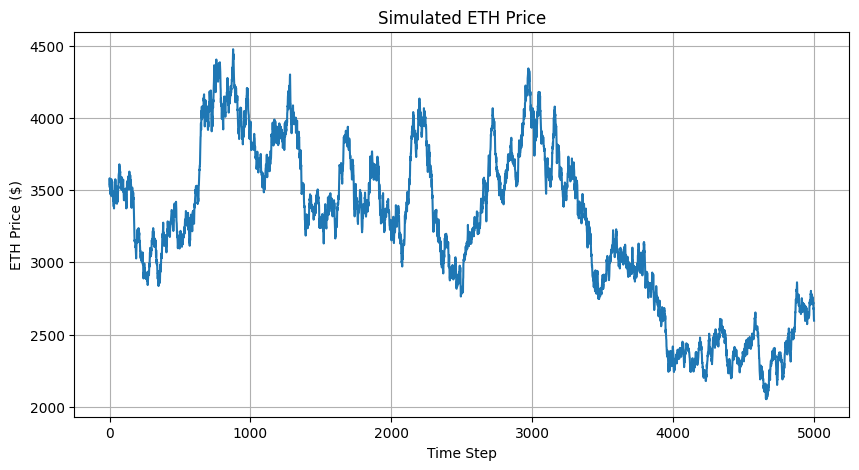

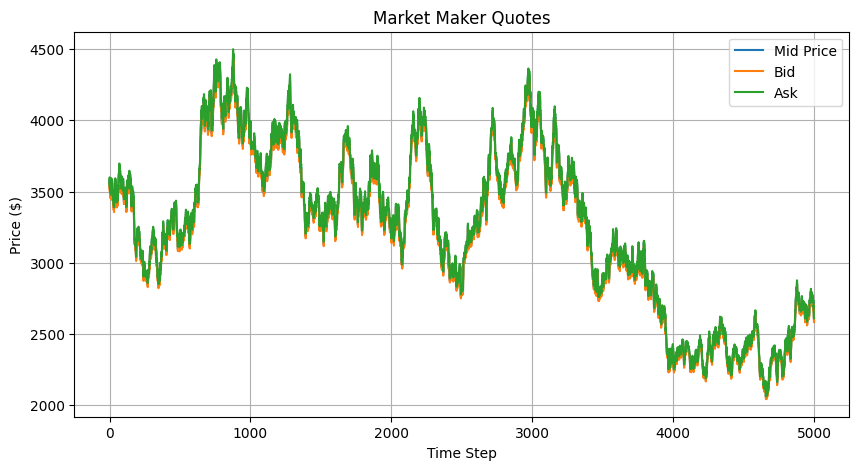

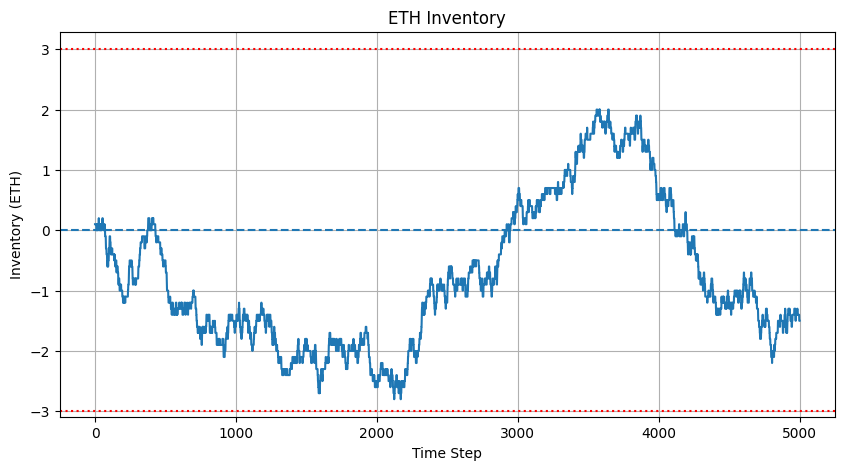

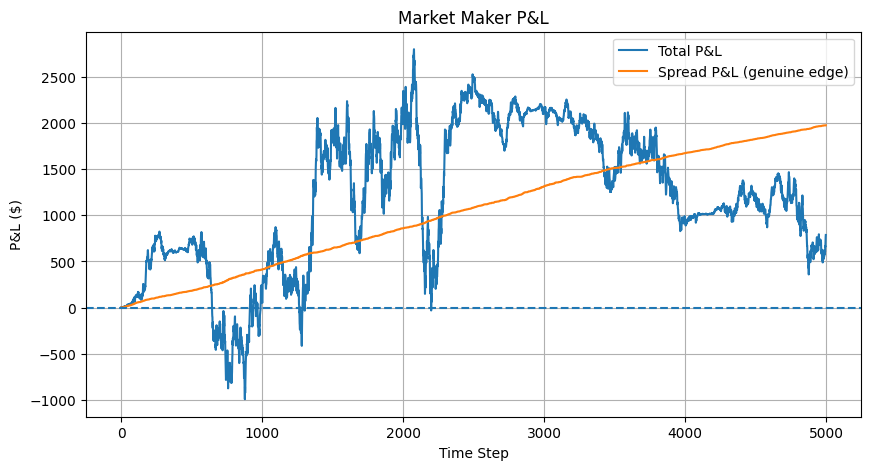

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# simulation parameters:

initial_price = 3500.0
steps = 5000

# price simulation:

volatility = 0.01
drift = 0.0

# market-making parameters:

spread_multiplier = 0.5
min_spread = 1.0
inventory_skew = 0.5
max_inventory = 3.0

# starting portfolio:

initial_cash = 10000.0
initial_inventory = 0.0

# probability of an incoming order:

order_probability = 0.25

# size of each trade:

order_size = 0.1

# eth price simulation using geometric brownian motion:

def simulate_price(price, volatility, drift):

    random_shock = np.random.normal()

    return price * (1 + drift + volatility * random_shock)

# market-making quotes:

# the half-spread now scales with the dollar size of a typical price move (price * volatility) instead of being a fixed $5.

def calculate_quotes(price, inventory, volatility, spread_multiplier, min_spread, inventory_skew):

    step_dollar_volatility = price * volatility

    half_spread = max(min_spread, spread_multiplier * step_dollar_volatility)

    inventory_adjustment = inventory_skew * inventory * abs(inventory)

    bid = price - half_spread - inventory_adjustment
    ask = price + half_spread - inventory_adjustment

    return bid, ask, half_spread

# order simulation:

def simulate_order(order_probability):

    if np.random.random() > order_probability:
        return None

    if np.random.random() < 0.5:
        return "buy"
    else:
        return "sell"

# market-making simulation:

# same loop as before, but fills are now rejected once they'd push inventory past max_inventory in either direction.

def run_simulation(initial_price, steps, volatility, drift, spread_multiplier, min_spread, inventory_skew, max_inventory, initial_cash, initial_inventory, order_probability, order_size):

    # current market conditions:

    price = initial_price

    # current portfolio:

    cash = initial_cash
    inventory = initial_inventory

    # store simulation results:

    prices = []
    bids = []
    asks = []

    inventories = []
    cash_values = []
    pnl_values = []

    spread_capture = 0.0
    spread_capture_values = []

    trade_times = []
    trade_prices = []
    trade_types = []

    blocked_orders = 0

    # main loop:

    for t in range(steps):

        price = simulate_price(price, volatility, drift)

        bid, ask, half_spread = calculate_quotes(price, inventory, volatility, spread_multiplier, min_spread, inventory_skew)

        order = simulate_order(order_probability)

        if order == "buy" and inventory - order_size < -max_inventory:
            order = None
            blocked_orders += 1

        if order == "sell" and inventory + order_size > max_inventory:
            order = None
            blocked_orders += 1

        if order == "buy":

            spread_capture += (ask - price) * order_size

            inventory -= order_size
            cash += ask * order_size

            trade_times.append(t)
            trade_prices.append(ask)
            trade_types.append("buy")

        elif order == "sell":

            spread_capture += (price - bid) * order_size

            inventory += order_size
            cash -= bid * order_size

            trade_times.append(t)
            trade_prices.append(bid)
            trade_types.append("sell")

        portfolio_value = cash + inventory * price

        initial_value = (initial_cash + initial_inventory * initial_price)

        pnl = portfolio_value - initial_value

        prices.append(price)
        bids.append(bid)
        asks.append(ask)

        inventories.append(inventory)
        cash_values.append(cash)
        pnl_values.append(pnl)

        spread_capture_values.append(spread_capture)

    return (
        np.array(prices),
        np.array(bids),
        np.array(asks),
        np.array(inventories),
        np.array(cash_values),
        np.array(pnl_values),
        np.array(spread_capture_values),
        np.array(trade_times),
        np.array(trade_prices),
        np.array(trade_types),
        blocked_orders)

# performance metrics:

def calculate_max_drawdown(pnl):

    cumulative_max = np.maximum.accumulate(pnl)

    drawdown = pnl - cumulative_max

    return np.min(drawdown)


def calculate_sharpe_ratio(pnl):

    returns = np.diff(pnl)

    if np.std(returns) == 0:
        return 0.0

    return np.mean(returns) / np.std(returns)

# run simulation and collect results:

(
    prices,
    bids,
    asks,
    inventories,
    cash_values,
    pnl,
    spread_capture_values,
    trade_times,
    trade_prices,
    trade_types,
    blocked_orders) = run_simulation(
    initial_price=initial_price,
    steps=steps,
    volatility=volatility,
    drift=drift,
    spread_multiplier=spread_multiplier,
    min_spread=min_spread,
    inventory_skew=inventory_skew,
    max_inventory=max_inventory,
    initial_cash=initial_cash,
    initial_inventory=initial_inventory,
    order_probability=order_probability,
    order_size=order_size
)

final_price = prices[-1]
final_inventory = inventories[-1]
final_pnl = pnl[-1]
final_spread_capture = spread_capture_values[-1]

max_drawdown = calculate_max_drawdown(pnl)
sharpe_ratio = calculate_sharpe_ratio(pnl)

number_of_trades = len(trade_times)

print("=" * 50)
print("ETH MARKET-MAKING SIMULATOR (v2: inventory limits)")
print("=" * 50)

print(f"Initial ETH price:     ${initial_price:.2f}")
print(f"Final ETH price:       ${final_price:.2f}")

print(f"Initial cash:          ${initial_cash:.2f}")
print(f"Final cash:            ${cash_values[-1]:.2f}")

print(f"Final inventory:       {final_inventory:.2f} ETH")
print(f"Max inventory allowed: {max_inventory:.2f} ETH")

print(f"Final P&L:             ${final_pnl:.2f}")
print(f"  of which spread pnl: ${final_spread_capture:.2f}")
print(f"  of which inventory:  ${final_pnl - final_spread_capture:.2f}")

print(f"Maximum drawdown:      ${max_drawdown:.2f}")

print(f"Number of trades:      {number_of_trades}")
print(f"Orders blocked (limit):{blocked_orders}")

print(f"Sharpe ratio:          {sharpe_ratio:.3f}")

print("=" * 50)

# plotting results:

# eth price:

plt.figure(figsize=(10, 5))

plt.plot(prices)

plt.title("Simulated ETH Price")
plt.xlabel("Time Step")
plt.ylabel("ETH Price ($)")

plt.grid()

plt.show()

# quotes:

plt.figure(figsize=(10, 5))

plt.plot(prices, label="Mid Price")
plt.plot(bids, label="Bid")
plt.plot(asks, label="Ask")

plt.title("Market Maker Quotes")
plt.xlabel("Time Step")
plt.ylabel("Price ($)")

plt.legend()
plt.grid()

plt.show()

# inventory:

plt.figure(figsize=(10, 5))

plt.plot(inventories)

plt.axhline(0, linestyle="--")
plt.axhline(max_inventory, linestyle=":", color="red")
plt.axhline(-max_inventory, linestyle=":", color="red")

plt.title("ETH Inventory")
plt.xlabel("Time Step")
plt.ylabel("Inventory (ETH)")

plt.grid()

plt.show()

# pnl, split into spread edge vs inventory swings:

plt.figure(figsize=(10, 5))

plt.plot(pnl, label="Total P&L")
plt.plot(spread_capture_values, label="Spread P&L (genuine edge)")

plt.axhline(0, linestyle="--")

plt.title("Market Maker P&L")
plt.xlabel("Time Step")
plt.ylabel("P&L ($)")

plt.legend()
plt.grid()

plt.show()